In [1]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
path_start = f"/pfs/10/work/hd_cu284-work2/fargo3d/outputs/"
path_endings=["fargo_fiducial_companion","fargo_fiducial_super_light_companion","fargo_fiducial_light_companion", "fargo_fiducial_heavy_companion",
              "fargo_fiducial_close_companion","fargo_fiducial_close_light_companion", "fargo_fiducial_companion_with_feelings",
              "fargo_fiducial_close_super_light_companion", "fargo_fiducial_closer_light_companion", "fargo_fiducial_closer_super_light_companion","fargo_fiducial_closer_companion", "fargo_fiducial" ]

titles = ["$r_1 = 2.28r_0$, $M_{p,2} = 2.5M_{jup}$","$r_1 = 2.28r_0$, $M_{p,2} = 0.56M_{jup}$", "$r_1 = 2.28r_0$, $M_{p,2} = 1.25M_{jup}$","$r_1 = 2.28r_0$, $M_p = 5M_{jup}$",
          "$r_1 = 2.0r_0$, $M_{p,2} = 2.5M_{jup}$", "$r_1 = 2.0r_0$, $M_{p,2} = 1.25M_{jup}$","$r_1 = 2.28r_0$, $M_{p,2} = 2.5M_{jup}$ feelings", 
          "$r_1 = 2.0r_0$, $M_{p,2} = 0.56M_{jup}$","$r_1 = 1.7r_0$, $M_{p,2} = 1.25M_{jup}$","$r_1 = 1.7r_0$, $M_{p,2} = 0.56M_{jup}$",
          "$r_1 = 1.7r_0$, $M_{p,2} = 2.5M_{jup}$", "fiducial, no companion"]
paths = []
for i in range(len(path_endings)):
    paths.append(path_start+path_endings[i])

In [3]:


frames = [0,1,10,100]

rho_cube=[] # first index: which alpha, second index: which snapshot.
for path in paths:
    rho_cube.append([])
    for i in frames:
        rho = np.fromfile(f"{path}/gasdens{i}.dat").reshape(300, 384)
        rho_cube[-1].append(rho)

rho_cube=np.array(rho_cube)

### calculate disk mass at dens=1
au  = 1.49598e13     # Astronomical Unit       [cm]
ms  = 1.98892e33     # Solar mass              [g]
mstar    = 1.08*ms #ms
r0       = 57*au    # The radius corresponding to '1' in dimensionless units

r_min = 0.3
r_max = 7

sigma_0 = 6.3661977237e-4 * mstar / (r0*r0)

rho_cube = rho_cube*mstar/r0**2
frame = frames[-1]

/scratch/3196255/ipykernel_3094985/3395106305.py:15: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[a][-1])-np.log10(rho_cube[a][0]),cmap=cm.Oranges_r, clim=(1,-3.5))


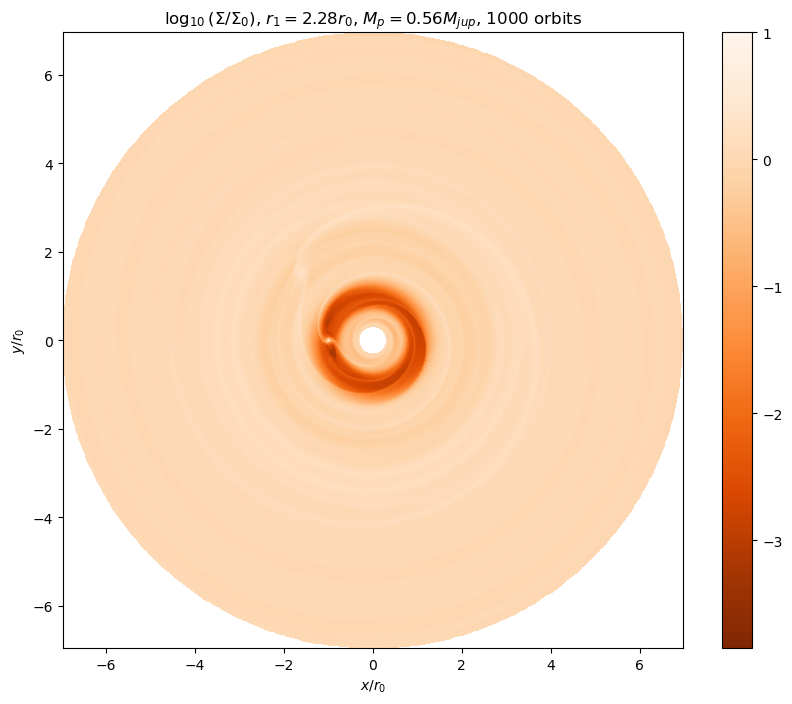

In [59]:
## make this a round plot so I know what's going on.

Nr = 300
Nphi = 384

r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]
phi = np.linspace(0, 2*np.pi, Nphi)

R, PHI = np.meshgrid(r_list, phi, indexing='ij')

X = R*np.cos(PHI)
Y = R*np.sin(PHI)
a=1
plt.figure(figsize=(10,8))
plt.pcolormesh(X, Y,np.log10(rho_cube[a][-1])-np.log10(rho_cube[a][0]),cmap=cm.Oranges_r, clim=(1,-3.5))
plt.title(f"$\\log_{{10}} \\left(\\Sigma/\\Sigma_0\\right)$, {titles[a]}, {(frames[-1])*10} orbits")
plt.colorbar()
plt.xlabel("$x/r_0$")
plt.ylabel("$y/r_0$")
#plt.xlim(-3,3)
#plt.ylim(-3,3)
plt.savefig("img/fargo_cartesian_fiducial.PNG")

# Examining eccentricities for different companion masses at $2.28 r_0$

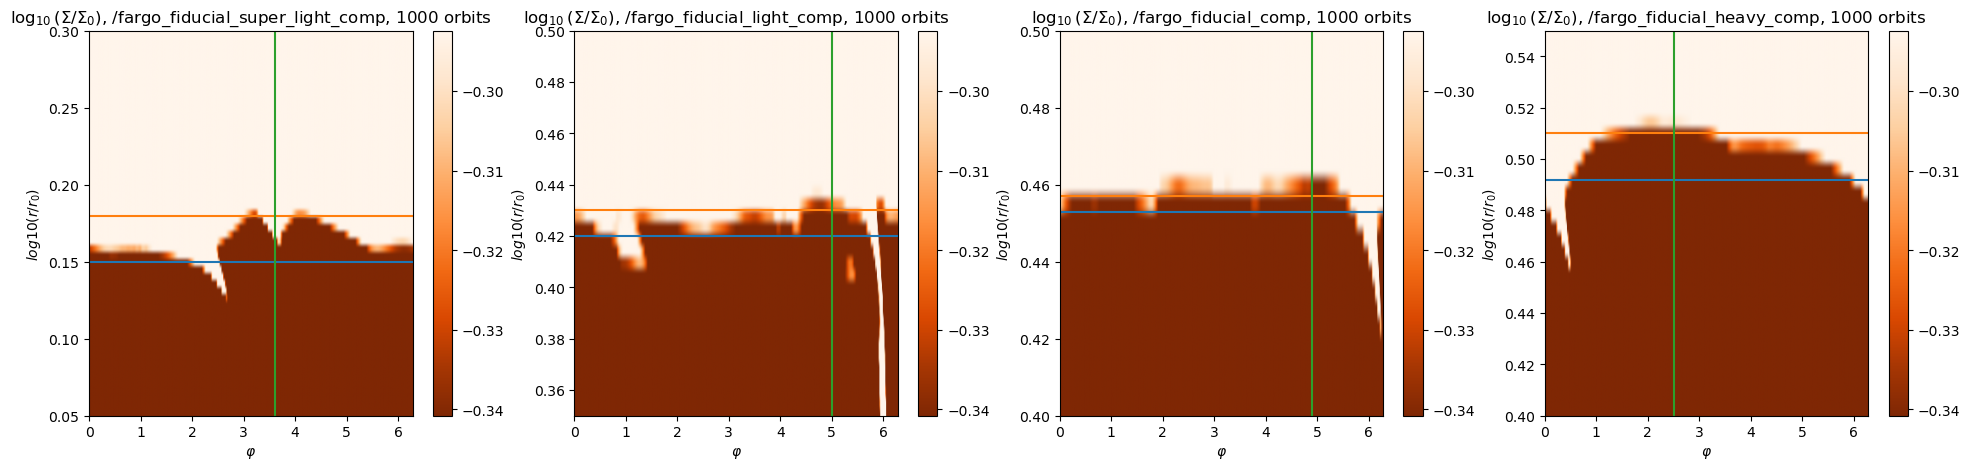

In [12]:
%matplotlib inline
r_min = 0.3
r_max = 7
index_for_comp_mass=[1,2,0,3]

r_in_log = [0.15,0.42,0.453,0.492]
r_out_log = [0.18,0.43,0.457,0.51]
phi_ellipse = [3.6,5,4.9,2.5]

ylim_lower = [0.05,0.35,0.4,0.4]
ylim_upper = [0.3,0.5,0.5,0.55]

plt.figure(figsize=(24,5))
frame = 100

for it,i in enumerate(index_for_comp_mass):
    path = paths[i]
    
        
    plt.subplot(1,4,it+1)
    
    plt.imshow(np.log10(rho_cube[i][-1]/rho_cube[i][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (np.log10(0.51),np.log10(0.49)))
    plt.plot([0,np.pi*2],[r_in_log[it],r_in_log[it]])
    plt.plot([0,np.pi*2],[r_out_log[it],r_out_log[it]])
    plt.plot([phi_ellipse[it], phi_ellipse[it]],[-0.5,0.8])
    plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
    plt.ylim(ylim_lower[it], ylim_upper[it])
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()


r_in: 1.4125375446227544
r_out: 1.5135612484362082
Eccentricity for /fargo_fiducial_super_light_comp: 0.03452504886475244


/scratch/3196255/ipykernel_3094985/968687571.py:33: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


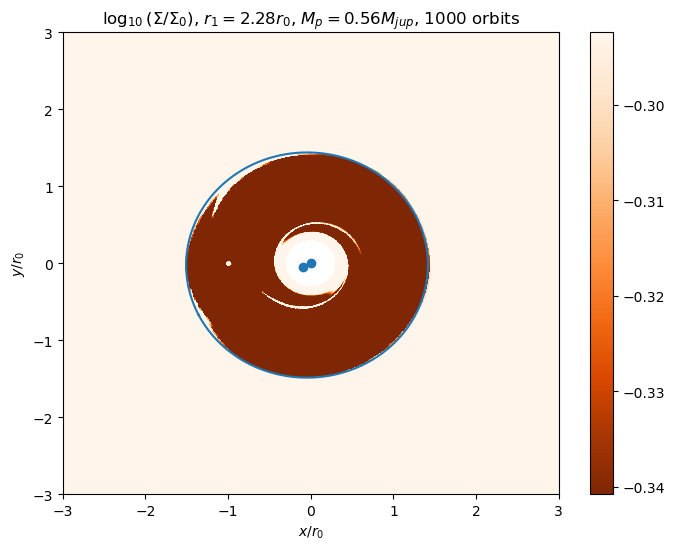

In [42]:

model_ind = [1,2,0,3][0]

"""
r_in_log = [0.15,0.42,0.453,0.492]
r_out_log = [0.18,0.43,0.457,0.51]
phi_ellipse = [3.6,5,4.9,2.5]
"""

r_in = np.power(10,0.15) # +- 0.005
r_out = np.power(10,0.18) # +- 0.005

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 3.6
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {titles[model_ind]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()
plt.xlabel("$x/r_0$")
plt.ylabel("$y/r_0$")
plt.savefig("img/not_strange_ecc.PNG", bbox_inches="tight")

r_in: 2.6302679918953817
r_out: 2.6915348039269156
Eccentricity for /fargo_fiducial_light_comp: 0.011512416822289862


/scratch/3196255/ipykernel_3094985/3145881754.py:33: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


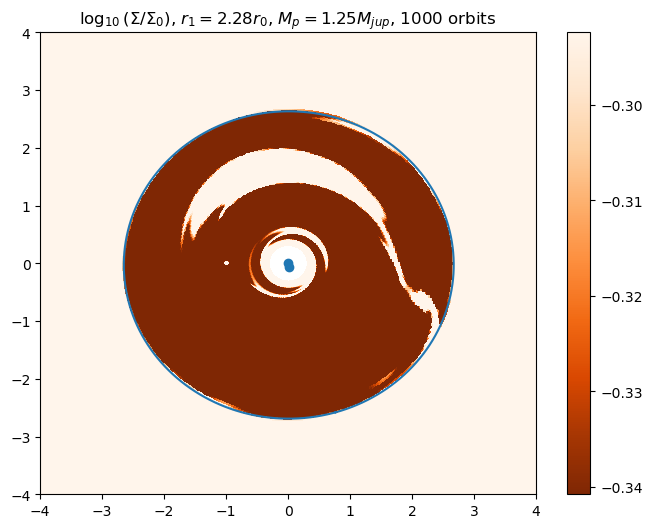

In [37]:

model_ind = [1,2,0,3][1]

"""
r_in_log = [0.15,0.42,0.453,0.492]
r_out_log = [0.18,0.43,0.457,0.51]
phi_ellipse = [3.6,5,4.9,2.5]
"""

r_in = np.power(10,0.42) #+- 0.005
r_out = np.power(10,0.43) #+- 0.005

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 5
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {titles[model_ind]}, {(frame)*10} orbits")
plt.xlim(-4,4)
plt.ylim(-4,4)
plt.xlabel("$x/r_0$")
plt.ylabel("$y/r_0$")
plt.colorbar()

r_in: 2.837919028441556
r_out: 2.864177969906581
Eccentricity for /fargo_fiducial_comp: 0.004605137631406831


/scratch/3196255/ipykernel_3094985/988064920.py:33: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


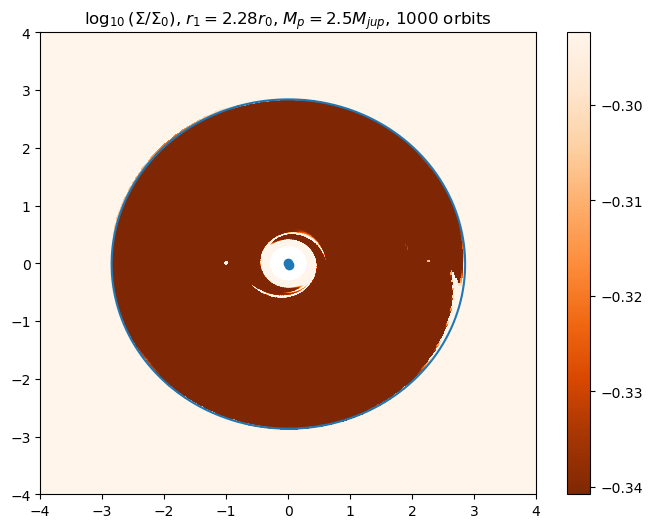

In [36]:

model_ind = [1,2,0,3][2]

"""
r_in_log = [0.15,0.42,0.453,0.492]
r_out_log = [0.18,0.43,0.457,0.51]
phi_ellipse = [3.6,5,4.9,2.5]
"""

r_in = np.power(10,0.453) #+- 0.005
r_out = np.power(10,0.457) #+- 0.005

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 4.9
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {titles[model_ind]}, {(frame)*10} orbits")
plt.xlim(-4,4)
plt.ylim(-4,4)
plt.xlabel("$x/r_0$")
plt.ylabel("$y/r_0$")
plt.colorbar()

r_in: 3.1045595881283554
r_out: 3.2359365692962827
Eccentricity for /fargo_fiducial_heavy_comp: 0.020720299785070694


/scratch/3196255/ipykernel_3094985/3798165701.py:33: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


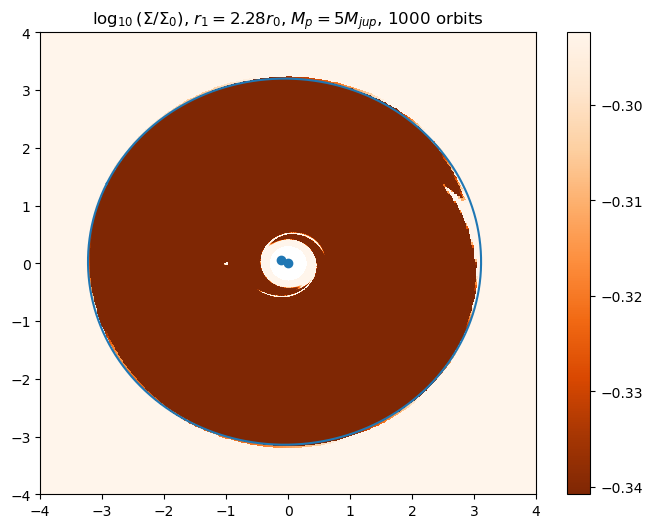

In [35]:

model_ind = [1,2,0,3][3]

"""
r_in_log = [0.15,0.42,0.453,0.492]
r_out_log = [0.18,0.43,0.457,0.51]
phi_ellipse = [3.6,5,4.9,2.5]
"""

r_in = np.power(10,0.492) #+- 0.005
r_out = np.power(10,0.51) #+- 0.005

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 2.7
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {titles[model_ind]}, {(frame)*10} orbits")
plt.xlim(-4,4)
plt.ylim(-4,4)
plt.xlabel("$x/r_0$")
plt.ylabel("$y/r_0$")
plt.colorbar()

[0.03452504886475244+/-0.008131163924281423
 0.011512416822289862+/-0.008139788711646296
 0.004605137631406831+/-0.008140695021813056
 0.020720299785070694+/-0.00813737254215859]


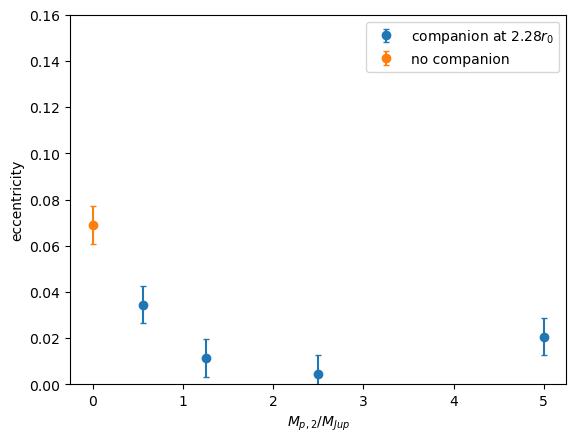

In [17]:
from uncertainties import ufloat

## make a plot for the eccentricities.


r_in_log = [ufloat(0.15,0.005),ufloat(0.42,0.005),ufloat(0.453,0.005),ufloat(0.492,0.005)]
r_out_log = [ufloat(0.18,0.005),ufloat(0.43,0.005),ufloat(0.457,0.005),ufloat(0.51,0.005)]

r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
print(ecc)
ecc_values = [ee.nominal_value for ee in ecc]
ecc_errs = [ee.std_dev for ee in ecc]

plt.errorbar([0.56,1.25,2.5,5],ecc_values, yerr = ecc_errs, fmt="o", capsize=2, label="companion at $2.28r_0$")
plt.xlabel("$M_{p,2}/M_{Jup}$")
plt.ylabel("eccentricity")
plt.ylim(0,0.16)


r_in_log_fid = ufloat(0.14,0.005)
r_out_log_fid = ufloat(0.20,0.005)



r_in = np.power(10,r_in_log_fid)
r_out = np.power(10, r_out_log_fid)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
ecc_value_fid  = ecc.nominal_value
ecc_err_fid= ecc.std_dev

plt.errorbar([0],[ecc_value_fid], yerr = [ecc_err_fid], fmt="o", capsize=2, label="no companion")
plt.legend()


# Again, but now for $2.0 r_0$

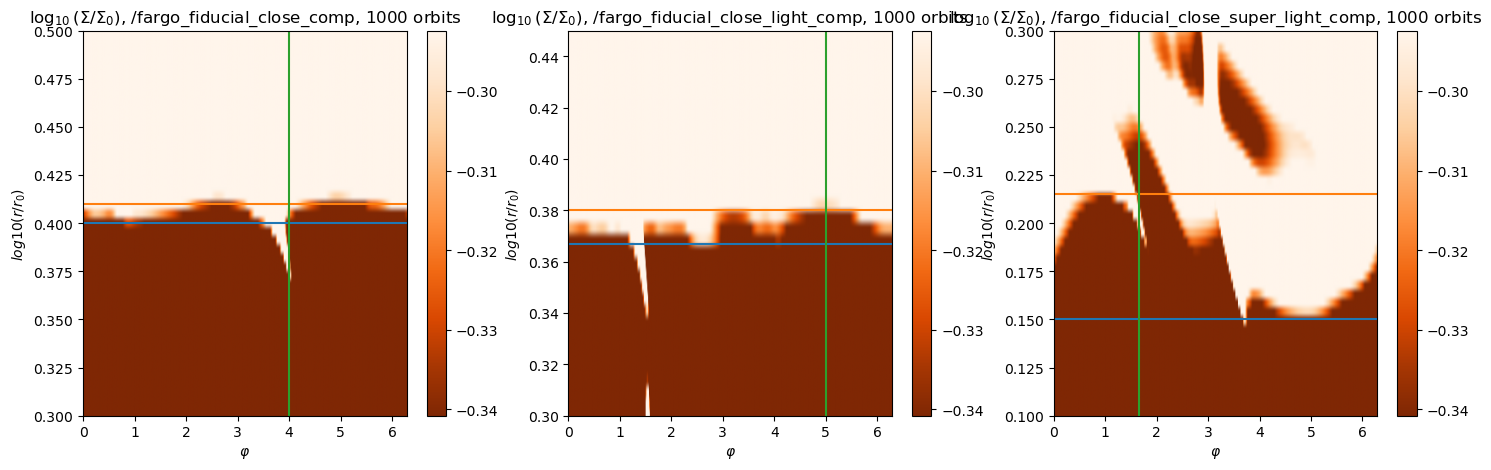

In [25]:
%matplotlib inline
r_min = 0.3
r_max = 7

#### careful, reversed order . . . ######
index_for_comp_close=[4,5,7]

r_in_log = [0.4,0.367,0.15]
r_out_log = [0.41,0.38,0.215]
phi_ellipse = [4.0,5,4.8-np.pi]

ylim_lower = [0.3,0.3,0.1]
ylim_upper = [0.5,0.45,0.3]

plt.figure(figsize=(24,5))
frame = 100

for it,i in enumerate(index_for_comp_close):
    path = paths[i]
    
        
    plt.subplot(1,4,it+1)
    
    plt.imshow(np.log10(rho_cube[i][-1]/rho_cube[i][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (np.log10(0.51),np.log10(0.49)))
    plt.plot([0,np.pi*2],[r_in_log[it],r_in_log[it]])
    plt.plot([0,np.pi*2],[r_out_log[it],r_out_log[it]])
    plt.plot([phi_ellipse[it], phi_ellipse[it]],[-0.5,0.8])
    plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
    plt.ylim(ylim_lower[it], ylim_upper[it])
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()


r_in: 2.51188643150958
r_out: 2.5703957827688635
Eccentricity for /fargo_fiducial_close_comp: 0.011512416822289791


/scratch/3196255/ipykernel_3094985/1237373186.py:33: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


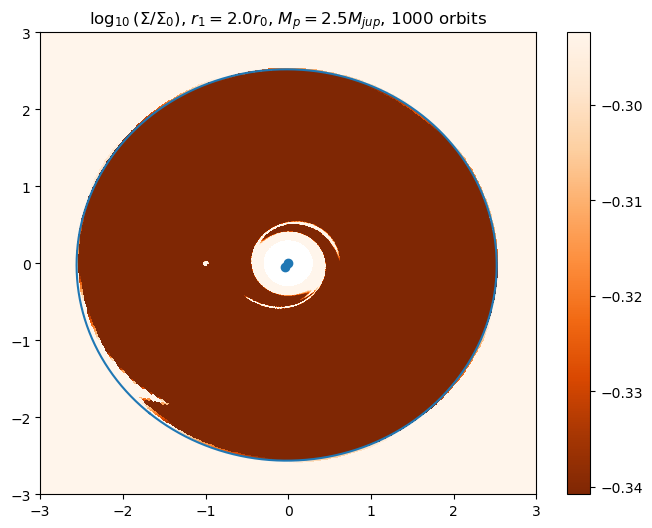

In [26]:

model_ind = [4,5,7][0]

"""
r_in_log = [0.4,0.367,0.15]
r_out_log = [0.41,0.38,0.215]
phi_ellipse = [4.0,5,4.8-np.pi]
"""

r_in = np.power(10,0.4) # +- 0.005
r_out = np.power(10,0.41) # +- 0.005

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 4.0
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {titles[model_ind]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.xlabel("$x/r_0$")
plt.ylabel("$y/r_0$")
plt.colorbar()

r_in: 2.328091257665008
r_out: 2.3988329190194904
Eccentricity for /fargo_fiducial_close_light_comp: 0.014965685657369903


/scratch/3196255/ipykernel_3094985/4037274968.py:33: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


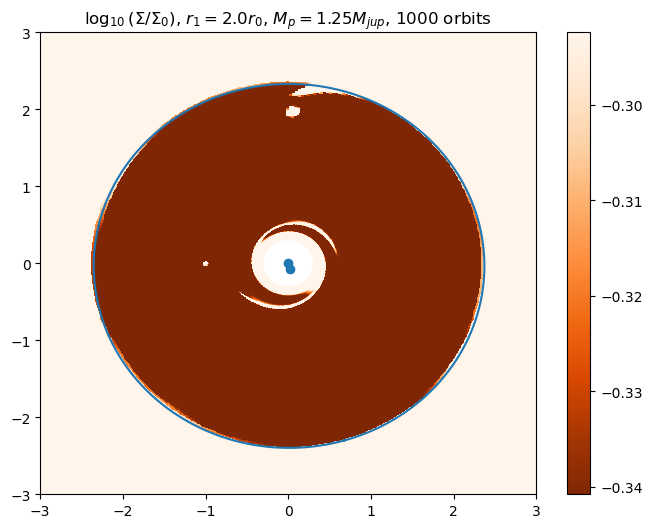

In [27]:

model_ind = [4,5,7][1]

"""
r_in_log = [0.4,0.367,0.15]
r_out_log = [0.41,0.38,0.215]
phi_ellipse = [4.0,5,4.8-np.pi]
"""

r_in = np.power(10,0.367) # +- 0.005
r_out = np.power(10,0.38) # +- 0.005

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 5.0
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {titles[model_ind]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.xlabel("$x/r_0$")
plt.ylabel("$y/r_0$")
plt.colorbar()

r_in: 1.4125375446227544
r_out: 1.6405897731995394
Eccentricity for /fargo_fiducial_close_super_light_comp: 0.07469463433298548


/scratch/3196255/ipykernel_3094985/42351128.py:34: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


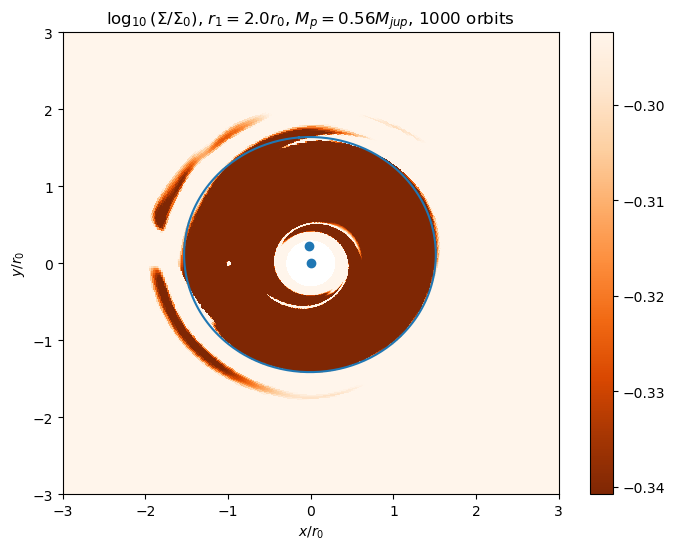

In [44]:

model_ind = [4,5,7][2]

"""
r_in_log = [0.4,0.367,0.15]
r_out_log = [0.41,0.38,0.215]
phi_ellipse = [4.0,5,4.8-np.pi]

"""

r_in = np.power(10,0.15) # +- 0.01
r_out = np.power(10,0.215) # +- 0.01

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 4.8-np.pi
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

#plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {titles[model_ind]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.xlabel("$x/r_0$")
plt.ylabel("$y/r_0$")
plt.colorbar()
plt.savefig("img/strange_ecc_point.PNG", bbox_inches="tight")

[0.011512416822289791+/-0.008139788711646298
 0.014965685657369903+/-0.008139044343220542
 0.07469463433298548+/-0.016190894838094497]


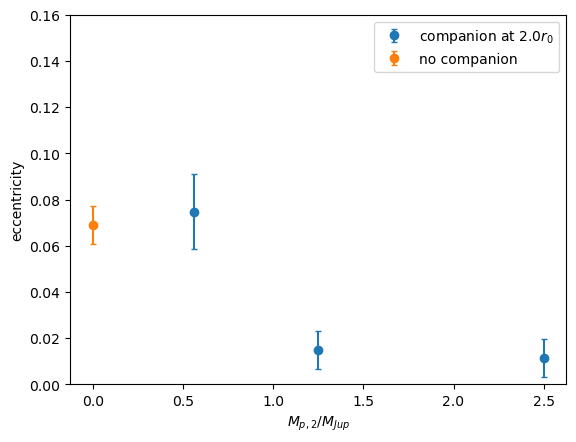

In [29]:

from uncertainties import ufloat
r_in_log = [0.4,0.367,0.15]
r_out_log = [0.41,0.38,0.215]
phi_ellipse = [4.0,5,4.8-np.pi]

r_in_log = [ufloat(0.4,0.005),ufloat(0.367,0.005),ufloat(0.15,0.01)]
r_out_log = [ufloat(0.41,0.005),ufloat(0.38,0.005),ufloat(0.215,0.01)]



r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
print(ecc)
ecc_values = [ee.nominal_value for ee in ecc]
ecc_errs = [ee.std_dev for ee in ecc]

plt.errorbar([2.5,1.25,0.56],ecc_values, yerr = ecc_errs, fmt="o", capsize=2, label="companion at $2.0r_0$")
plt.xlabel("$M_{p,2}/M_{Jup}$")
plt.ylabel("eccentricity")
plt.ylim(0,0.16)


r_in_log_fid = ufloat(0.14,0.005)
r_out_log_fid = ufloat(0.20,0.005)



r_in = np.power(10,r_in_log_fid)
r_out = np.power(10, r_out_log_fid)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
ecc_value_fid  = ecc.nominal_value
ecc_err_fid= ecc.std_dev

plt.errorbar([0],[ecc_value_fid], yerr = [ecc_err_fid], fmt="o", capsize=2, label="no companion")
plt.legend()

# Again, for $1.7 r_0$

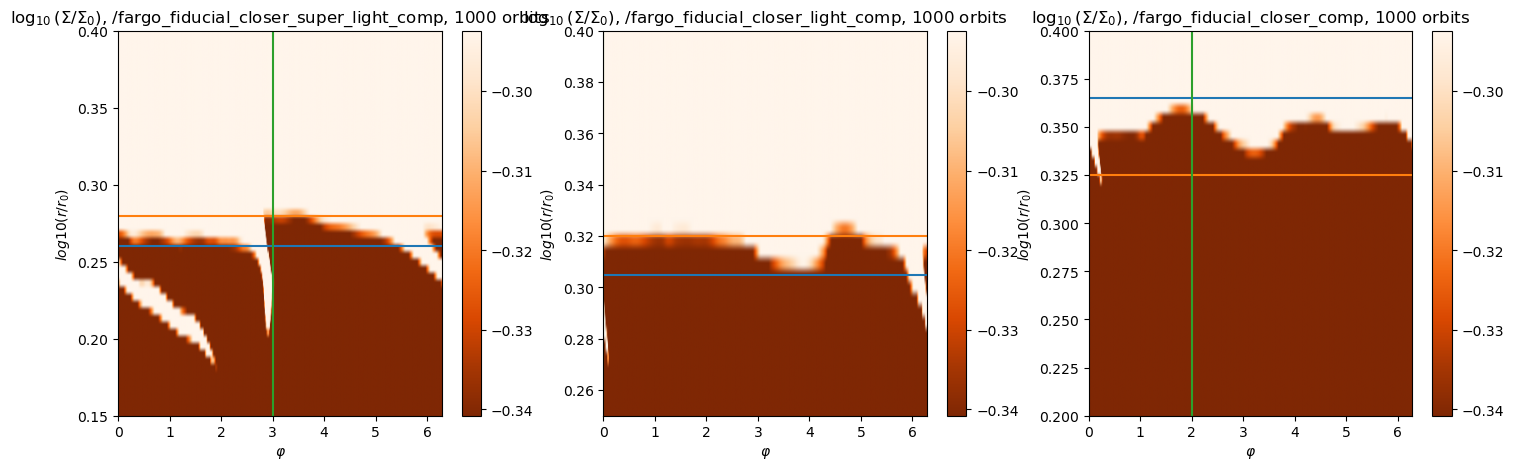

In [30]:
%matplotlib inline
r_min = 0.3
r_max = 7
index_for_closer=[9,8,10]

r_in_log = [0.26,0.305,0.365]
r_out_log = [0.28,0.32,0.325]
phi_ellipse = [3,0,2]

ylim_lower = [0.15,0.25,0.2]
ylim_upper = [0.4,0.4,0.4]

plt.figure(figsize=(24,5))
frame = 100

for it,i in enumerate(index_for_closer):
    path = paths[i]
    
        
    plt.subplot(1,4,it+1)
    
    plt.imshow(np.log10(rho_cube[i][-1]/rho_cube[i][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (np.log10(0.51),np.log10(0.49)))
    plt.plot([0,np.pi*2],[r_in_log[it],r_in_log[it]])
    plt.plot([0,np.pi*2],[r_out_log[it],r_out_log[it]])
    plt.plot([phi_ellipse[it], phi_ellipse[it]],[-0.5,0.8])
    plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
    plt.ylim(ylim_lower[it], ylim_upper[it])
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()


r_in: 1.8197008586099834
r_out: 1.9054607179632472
Eccentricity for /fargo_fiducial_closer_super_light_comp: 0.023021782435583407


/scratch/3196255/ipykernel_3094985/169774300.py:27: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


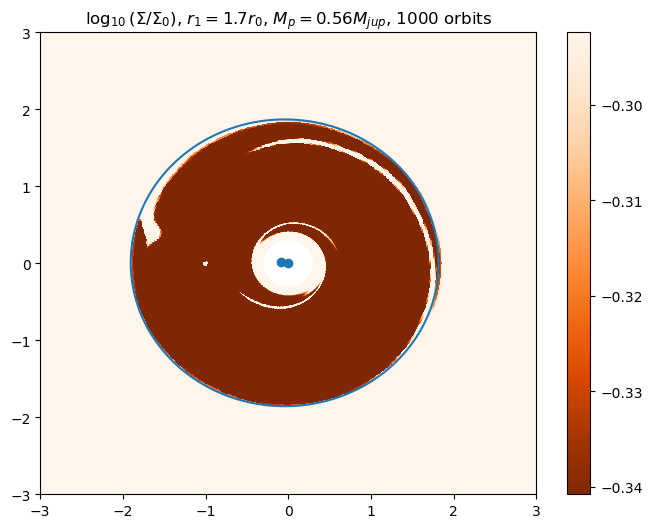

In [31]:

model_ind = [9,8,10][0]

r_in = np.power(10,0.26) # +- 0.005
r_out = np.power(10,0.28) # +- 0.005

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 3.0
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {titles[model_ind]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.xlabel("$x/r_0$")
plt.ylabel("$y/r_0$")
plt.colorbar()

r_in: 2.0183663636815607
r_out: 2.0892961308540396
Eccentricity for /fargo_fiducial_closer_light_comp: 0.01726767164216543


/scratch/3196255/ipykernel_3094985/197480797.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


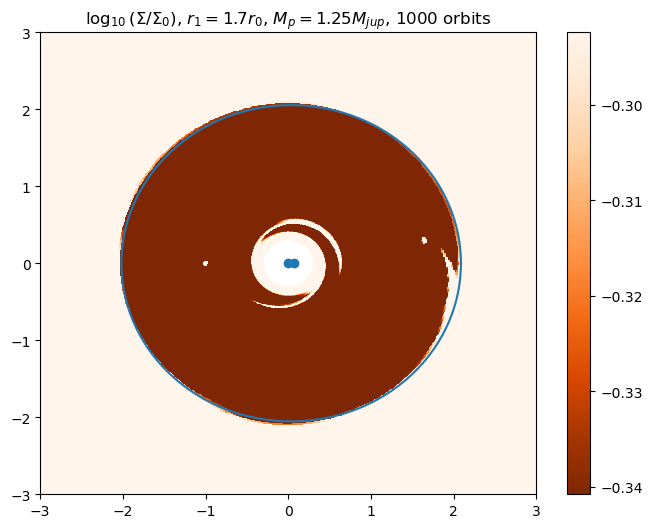

In [32]:

model_ind = [9,8,10][1]


r_in = np.power(10,0.305) # +- 0.005
r_out = np.power(10,0.32) # +- 0.005

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 0.0
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {titles[model_ind]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.xlabel("$x/r_0$")
plt.ylabel("$y/r_0$")
plt.colorbar()

r_in: 2.2130947096056377
r_out: 2.2490546058357808
Eccentricity for /fargo_fiducial_closer_comp: 0.008058873356322395


/scratch/3196255/ipykernel_3094985/1043035321.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


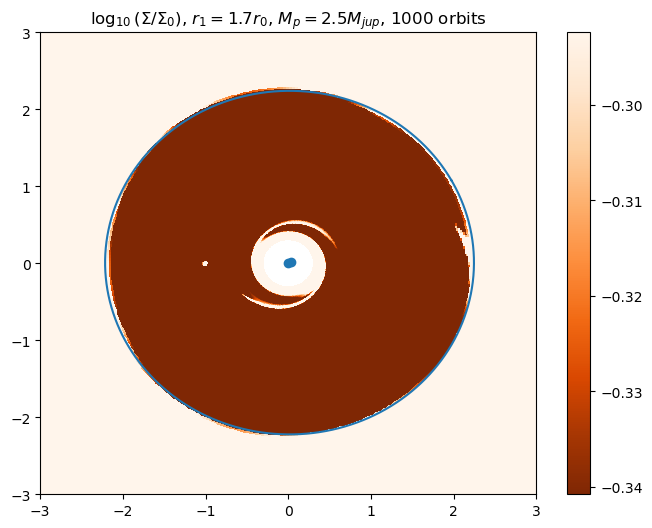

In [33]:

model_ind = [9,8,10][2]


r_in = np.power(10,0.345) # +- 0.005
r_out = np.power(10,0.352) # +- 0.005

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 0.5
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {titles[model_ind]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.xlabel("$x/r_0$")
plt.ylabel("$y/r_0$")
plt.colorbar()

[0.023021782435583407+/-0.008136552987632377
 0.01726767164216543+/-0.008138440284841853
 0.008058873356322395+/-0.008140338955344927]


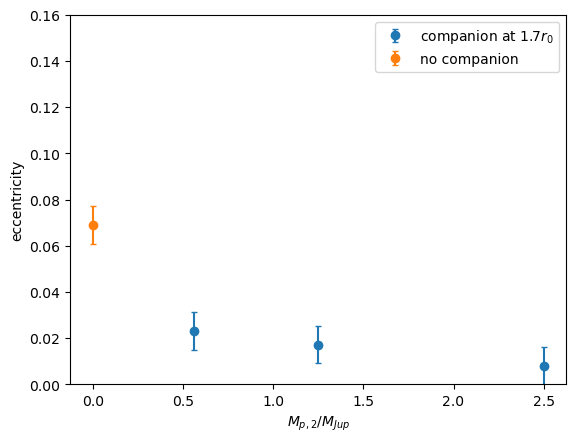

In [34]:

from uncertainties import ufloat

r_in_log = [ufloat(0.26,0.005),ufloat(0.305,0.005),ufloat(0.345, 0.005)]
r_out_log = [ufloat(0.28,0.005),ufloat(0.32,0.005), ufloat(0.352, 0.005)]



r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
print(ecc)
ecc_values = [ee.nominal_value for ee in ecc]
ecc_errs = [ee.std_dev for ee in ecc]

plt.errorbar([0.56,1.25,2.5],ecc_values, yerr = ecc_errs, fmt="o", capsize=2, label="companion at $1.7r_0$")
plt.xlabel("$M_{p,2}/M_{Jup}$")
plt.ylabel("eccentricity")
plt.ylim(0,0.16)


r_in_log_fid = ufloat(0.14,0.005)
r_out_log_fid = ufloat(0.20,0.005)



r_in = np.power(10,r_in_log_fid)
r_out = np.power(10, r_out_log_fid)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
ecc_value_fid  = ecc.nominal_value
ecc_err_fid= ecc.std_dev

plt.errorbar([0],[ecc_value_fid], yerr = [ecc_err_fid], fmt="o", capsize=2, label="no companion")
plt.legend()

# Summary

[0.023021782435583407+/-0.008136552987632377
 0.01726767164216543+/-0.008138440284841853
 0.008058873356322395+/-0.008140338955344927]


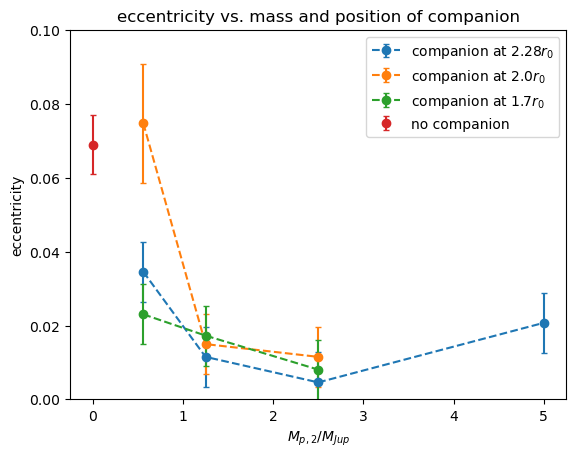

In [8]:
from uncertainties import ufloat
#normal companion (2.28 r_0)
r_in_log = [ufloat(0.15,0.005),ufloat(0.42,0.005),ufloat(0.453,0.005),ufloat(0.492,0.005)]
r_out_log = [ufloat(0.18,0.005),ufloat(0.43,0.005),ufloat(0.457,0.005),ufloat(0.51,0.005)]

r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc_norm = e/a
ecc_values_norm = [ee.nominal_value for ee in ecc_norm]
ecc_errs_norm = [ee.std_dev for ee in ecc_norm]


plt.errorbar([0.56,1.25,2.5,5],ecc_values_norm, yerr = ecc_errs_norm, fmt="o--", capsize=2, label="companion at $2.28r_0$")

# close companion
#r_in_log = [ufloat(0.4,0.005),ufloat(0.367,0.005),ufloat(0.15,0.01)]
#r_out_log = [ufloat(0.41,0.005),ufloat(0.38,0.005),ufloat(0.215,0.01)]

r_in_log = [ufloat(0.15,0.01),ufloat(0.367,0.005),ufloat(0.4,0.005)]
r_out_log = [ufloat(0.215,0.01),ufloat(0.38,0.005),ufloat(0.41,0.005)]

r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)
a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc_close = e/a
ecc_values_close = [ee.nominal_value for ee in ecc_close]
ecc_errs_close = [ee.std_dev for ee in ecc_close]



plt.errorbar([0.56,1.25,2.5],ecc_values_close, yerr = ecc_errs_close, fmt="o--", capsize=2, label="companion at $2.0r_0$")
## closer companion


r_in_log = [ufloat(0.26,0.005),ufloat(0.305,0.005),ufloat(0.345, 0.005)]
r_out_log = [ufloat(0.28,0.005),ufloat(0.32,0.005), ufloat(0.352, 0.005)]



r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc_closer = e/a
ecc_values_closer = [ee.nominal_value for ee in ecc_closer]
ecc_errs_closer = [ee.std_dev for ee in ecc_closer]
print(ecc_closer)


plt.errorbar([0.56,1.25,2.5],ecc_values_closer, yerr = ecc_errs_closer, fmt="o--", capsize=2, label="companion at $1.7r_0$")

## no companion

r_in_log_fid = ufloat(0.14,0.005)
r_out_log_fid = ufloat(0.20,0.005)



r_in = np.power(10,r_in_log_fid)
r_out = np.power(10, r_out_log_fid)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
ecc_value_fid  = ecc.nominal_value
ecc_err_fid= ecc.std_dev

plt.errorbar([0],[ecc_value_fid], yerr = [ecc_err_fid], fmt="o", capsize=2, label="no companion")
plt.legend()

plt.xlabel("$M_{p,2}/M_{Jup}$")
plt.ylabel("eccentricity")
plt.ylim(0,0.10)
plt.title("eccentricity vs. mass and position of companion")
plt.savefig("img/eccentricity_companion.PNG")
#plt.xscale("log")
#plt.yscale("log")

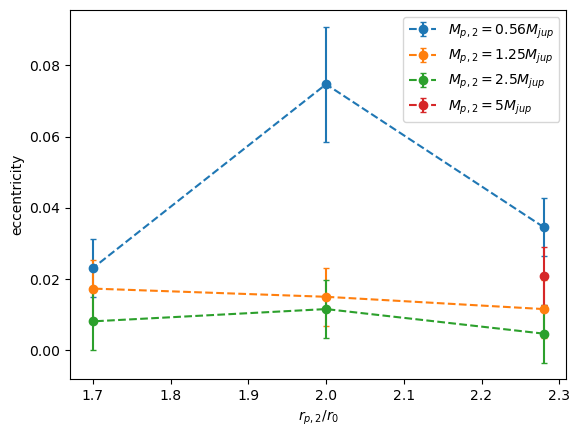

In [5]:
ecc_super_light = [ecc_norm[0], ecc_close[0], ecc_closer[0]]
ecc_super_light_val = [ee.nominal_value for ee in ecc_super_light]
ecc_super_light_err = [ee.std_dev for ee in ecc_super_light]

ecc_light = [ecc_norm[1], ecc_close[1], ecc_closer[1]]
ecc_light_val = [ee.nominal_value for ee in ecc_light]
ecc_light_err = [ee.std_dev for ee in ecc_light]

ecc_n = [ecc_norm[2], ecc_close[2], ecc_closer[2]]
ecc_n_val = [ee.nominal_value for ee in ecc_n]
ecc_n_err = [ee.std_dev for ee in ecc_n]

ecc_heavy = [ecc_norm[3]]
ecc_heavy_val = [ee.nominal_value for ee in ecc_heavy]
ecc_heavy_err = [ee.std_dev for ee in ecc_heavy]

plt.errorbar([2.28,2.0,1.7],ecc_super_light_val, yerr = ecc_super_light_err, fmt="o--", capsize=2, label="$M_{p,2} = 0.56 M_{jup}$")
plt.errorbar([2.28,2.0,1.7],ecc_light_val, yerr = ecc_light_err, fmt="o--", capsize=2, label="$M_{p,2} = 1.25 M_{jup}$")
plt.errorbar([2.28,2.0,1.7],ecc_n_val, yerr = ecc_n_err, fmt="o--", capsize=2, label="$M_{p,2} = 2.5 M_{jup}$")
plt.errorbar([2.28],ecc_heavy_val, yerr = ecc_heavy_err, fmt="o--", capsize=2, label="$M_{p,2} = 5 M_{jup}$")

plt.legend()
plt.xlabel("$r_{p,2}/r_0$")
plt.ylabel("eccentricity")
plt.savefig("img/eccentricity_companion_position.PNG")